## CÓDIGO PARA ESTIMACIÓN DE LAS NUEVAS DISTANCIAS CON LA CLUSTERIZACIÓN REALIZADA

Cargamos los viajes potenciales después de la clusterización y la ubicación de los nuevos clusters

In [ ]:
import pandas as pd

viajes = pd.read_csv("potenciales_viajes_cubiertos.csv")

In [ ]:
centroids=pd.read_csv("centroides2.csv")


In [ ]:
import pandas as pd
import osmnx as ox
import networkx as nx

centroids = centroids.rename(columns={'cluster': 'clusterOrigen', 'lat': 'lat_origen', 'lon': 'lon_origen'})
viajes = pd.merge(viajes, centroids[['clusterOrigen', 'lat_origen', 'lon_origen']], on='clusterOrigen', how='left')

centroids = centroids.rename(columns={'clusterOrigen': 'clusterFinal', 'lat_origen': 'lat_destino', 'lon_origen': 'lon_destino'})
viajes = pd.merge(viajes, centroids[['clusterFinal', 'lat_destino', 'lon_destino']], on='clusterFinal', how='left')

# Verificar el DataFrame 'viajes'
print("DataFrame 'viajes' después de la fusión:")
viajes

DataFrame 'viajes' después de la fusión:


,Unnamed: 0,idS,tsO,tsD,price,tt,dis,vel,lonO,latO,...,clusterOrigen,clusterFinal,origin_lat,origin_lon,destination_lat,destination_lon,lat_origen,lon_origen,lat_destino,lon_destino
0,0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,...,174.0,122.0,NaN,NaN,NaN,NaN,41.866389,12.465863,41.857323,12.472578
1,1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,...,59.0,98.0,NaN,NaN,NaN,NaN,41.923496,12.469619,41.937027,12.466458
2,2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,...,98.0,137.0,NaN,NaN,NaN,NaN,41.937027,12.466458,41.929623,12.487613
3,4,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,...,137.0,113.0,NaN,NaN,NaN,NaN,41.929623,12.487613,41.905160,12.458295
4,5,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,...,113.0,179.0,NaN,NaN,NaN,NaN,41.905160,12.458295,41.907179,12.462355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20392,24201,Z9W9,2021-02-23 09:16:54,2021-02-23 09:34:23,3.6225,1049,4660.137356,15.992845,12.522751,41.880051,...,177.0,84.0,NaN,NaN,NaN,NaN,41.880648,12.522372,41.902144,12.481032
20393,24202,Z9W9,2021-02-25 12:13:33,2021-02-25 12:22:03,2.2750,510,2465.595903,17.404206,12.481302,41.900674,...,189.0,29.0,NaN,NaN,NaN,NaN,41.899386,12.481817,41.894849,12.501414
20394,24203,Z9W9,2021-02-25 12:50:13,2021-02-25 12:57:14,2.0525,421,2385.131061,20.395420,12.501860,41.894429,...,29.0,189.0,NaN,NaN,NaN,NaN,41.894849,12.501414,41.899386,12.481817
20395,24204,Z9W9,2021-02-26 13:34:13,2021-02-26 13:38:53,1.7000,280,1193.360009,15.343200,12.481623,41.900672,...,189.0,129.0,NaN,NaN,NaN,NaN,41.899386,12.481817,41.893402,12.487132


Cargamos el mapa de roma que tiene las restricciones de tráfico como vehículo. Utilizamos el siguiente código para generar el mapa de nodos de roma yendo por la carretera o por el carril bici en los tramos que dispongan. Guardamos el mapa de nodos en un archivo .graphml para no tener que volver a generar el mapa.
```
# Grafo para vehículos (carreteras para coches)
graph_drive = ox.graph_from_place(place_name, network_type='drive')

# Grafo para carriles bici
graph_bike = ox.graph_from_place(place_name, network_type='bike')

combined_graph = nx.compose(graph_drive, graph_bike)
ox.save_graphml(combined_graph, filepath="rome_combined.graphml")
```

In [ ]:
G = ox.load_graphml("rome_combined.graphml")

Realizamos un preprocesado que indexa el id de cada nodo más cercano a cada uno de nuestros clusters. Esto nos permite hace no tener que buscarlos por cada uno de los viajes y permite mapear más rápido.

In [ ]:
print("\nPre-calculando nodos de OSMnx para cada cluster...")

# Unimos las coordenadas de origen y destino para crear un listado único de clusters/centroides
clusters_unicos = pd.concat([
    viajes[['clusterOrigen', 'lat_origen', 'lon_origen']].rename(columns={'clusterOrigen': 'cluster', 'lat_origen': 'lat', 'lon_origen': 'lon'}),
    viajes[['clusterFinal', 'lat_destino', 'lon_destino']].rename(columns={'clusterFinal': 'cluster', 'lat_destino': 'lat', 'lon_destino': 'lon'})
]).drop_duplicates(subset=['cluster']).dropna()

# Función para obtener el nodo más cercano
def get_nearest_node(row, graph):
    try:
        # Nota: OSMnx espera (lon, lat)
        return ox.nearest_nodes(graph, row['lon'], row['lat'])
    except Exception:
        return None

# Calcular el nodo OSMnx para cada centroide único
clusters_unicos['osmnx_node'] = clusters_unicos.apply(
    lambda row: get_nearest_node(row, G),
    axis=1
)


Pre-calculando nodos de OSMnx para cada cluster...


La siguiente función calcula la distancia más corta entre nodos teniendo en cuenta las restricciones del mapa de nodos.

In [ ]:
def calcular_distancia_osmnx_manual(row, graph):
    orig_node = row['node_origen']
    dest_node = row['node_destino']

    if orig_node is None or dest_node is None:
        return None

    try:
        # 1. Calcular la ruta (lista de nodos)
        route = ox.shortest_path(graph, orig_node, dest_node, weight='length')

        if route is None:
            return None # No se encontró ruta

        # 2. CALCULAR DISTANCIA MANUALMENTE (Lógica que funciona con tu versión de OSMnx)
        route_distancia = 0
        for u, v in nx.utils.pairwise(route):
            edge_data = graph.get_edge_data(u, v)
            # Asegurarse de que el borde existe y tiene datos
            if edge_data and 0 in edge_data and 'length' in edge_data[0]:
                 route_distancia += edge_data[0]['length']

        return route_distancia

    except nx.NetworkXNoPath:
        # Los nodos están en componentes desconectados.
        return None
    except Exception:
        # Error inesperado para esta fila
        return None

In [ ]:
from tqdm.auto import tqdm # Importamos la versión automática
# Importamos la extensión de pandas
tqdm.pandas()
print(f"\n🚀 Iniciando cálculo de {len(viajes)} viajes con barra de progreso...")

# Aplicamos la función usando .progress_apply()
viajes['nueva_distancia'] = viajes.progress_apply(
    calcular_distancia_osmnx_manual,
    axis=1,
    graph=G # Pasamos el grafo como argumento fijo
)

print("\n🎉 Cálculo completado.")

# --- 3. RESULTADO ---
print("Resultado comparativo:")
viajes[['clusterOrigen', 'clusterFinal', 'dis', 'nueva_distancia']]


🚀 Iniciando cálculo de 20397 viajes con barra de progreso...


  0%|          | 0/20397 [00:00<?, ?it/s]


🎉 Cálculo completado.
Resultado comparativo:


,clusterOrigen,clusterFinal,dis,nueva_distancia
0,174.0,122.0,1715.336751,1392.495456
1,59.0,98.0,1234.472044,2324.982278
2,98.0,137.0,2221.481536,4681.383030
3,137.0,113.0,4562.843566,5432.586749
4,113.0,179.0,550.154792,726.153311
...,...,...,...,...
20392,177.0,84.0,4660.137356,5070.890263
20393,189.0,29.0,2465.595903,2100.242735
20394,29.0,189.0,2385.131061,2419.978539
20395,189.0,129.0,1193.360009,998.367014


Comparativa entre la antigua distancia y la distancia real

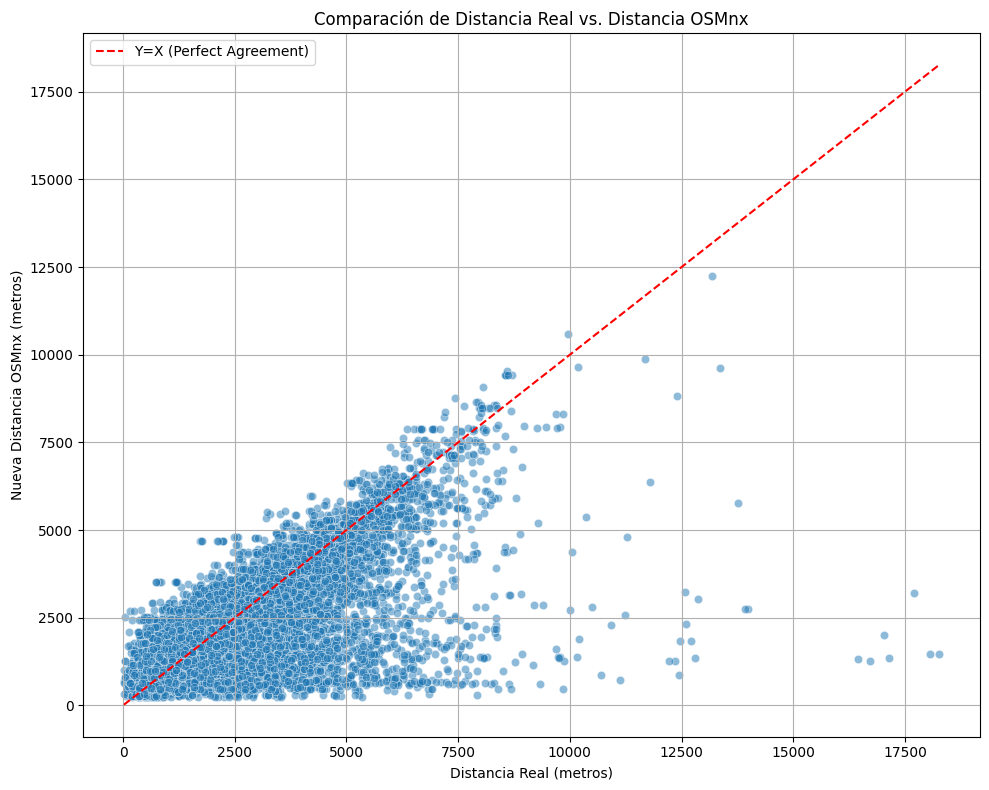

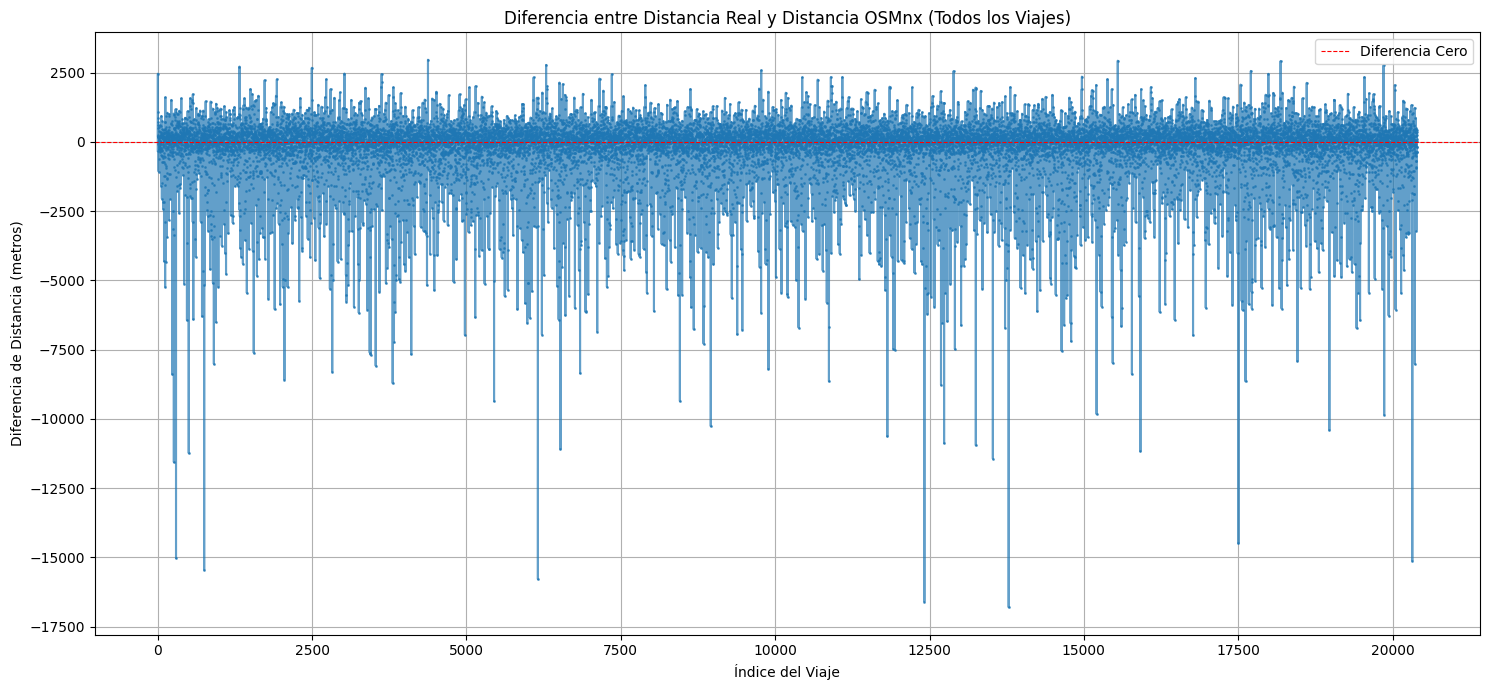

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Drop rows where 'nueva_distancia' is None, as they couldn't be calculated
# This also converts the column to a numeric type if it wasn't already
viajes_cleaned = viajes.dropna(subset=['nueva_distancia']).copy()

# --- Plot 1: Scatter plot of original vs. new distance ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x='dis', y='nueva_distancia', data=viajes_cleaned, alpha=0.5)

# Add a y=x line for perfect agreement
max_val = max(viajes_cleaned['dis'].max(), viajes_cleaned['nueva_distancia'].max())
min_val = min(viajes_cleaned['dis'].min(), viajes_cleaned['nueva_distancia'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Y=X (Perfect Agreement)')

plt.title('Comparación de Distancia Real vs. Distancia OSMnx')
plt.xlabel('Distancia Real (metros)')
plt.ylabel('Nueva Distancia OSMnx (metros)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Evolutionary plot of the difference for all trips ---
viajes_cleaned['diferencia_distancia'] = viajes_cleaned['nueva_distancia'] - viajes_cleaned['dis']

plt.figure(figsize=(15, 7))
plt.plot(viajes_cleaned.index, viajes_cleaned['diferencia_distancia'], marker='.', linestyle='-', markersize=2, alpha=0.7)
plt.title('Diferencia entre Distancia Real y Distancia OSMnx (Todos los Viajes)')
plt.xlabel('Índice del Viaje')
plt.ylabel('Diferencia de Distancia (metros)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Diferencia Cero')
plt.legend()
plt.tight_layout()
plt.show()

Guardamos los resultados

In [ ]:
viajes.drop(columns=['Unnamed: 0', 'origin_lat', 'origin_lon', 'destination_lat',
       'destination_lon','duration_calc'],inplace=True)
viajes.rename(columns={'tt':'Old Time', 'dis': 'Old Dis','lat_origen':'Lat ClusterOrigin', 'lon_origen':'Lon ClusterOrigin', 'lat_destino':'Lat ClusterDest',
       'lon_destino':'Lon ClusterDest', 'node_origen':'Osmnx Origen','node_destino':'Osmnx Destino', 'nueva_distancia':'New Dis' },inplace=True)

In [ ]:
viajes.head()

,idS,tsO,tsD,price,Old Time,Old Dis,vel,lonO,latO,lonD,latD,clusterOrigen,clusterFinal,Lat ClusterOrigin,Lon ClusterOrigin,Lat ClusterDest,Lon ClusterDest,Osmnx Origen,Osmnx Destino,New Dis
0,A0H4,2021-02-03 18:10:03,2021-02-03 18:17:44,2.1525,461,1715.336751,13.395254,12.466222,41.867388,12.470660,41.853908,174.0,122.0,41.866389,12.465863,41.857323,12.472578,306297749,1119847027,1392.495456
1,A0H4,2021-02-13 18:21:13,2021-02-13 18:25:33,1.6500,260,1234.472044,17.092690,12.471143,41.923692,12.467502,41.934306,59.0,98.0,41.923496,12.469619,41.937027,12.466458,297720062,300084997,2324.982278
2,A0H4,2021-02-14 13:39:54,2021-02-14 13:48:03,2.2225,489,2221.481536,16.354465,12.467524,41.934342,12.486330,41.928270,98.0,137.0,41.937027,12.466458,41.929623,12.487613,300084997,291637771,4681.383030
3,A0H4,2021-02-14 14:37:53,2021-02-14 14:57:53,4.0000,1200,4562.843566,13.688531,12.486275,41.928301,12.457922,41.904302,137.0,113.0,41.929623,12.487613,41.905160,12.458295,291637771,3577043693,5432.586749
4,A0H4,2021-02-15 13:31:24,2021-02-15 13:34:45,1.5025,201,550.154792,9.853519,12.457876,41.904303,12.460773,41.907606,113.0,179.0,41.905160,12.458295,41.907179,12.462355,3577043693,246677431,726.153311


In [ ]:
viajes.to_csv('viajes_potenciales_con_distancias.csv',index=False)

## Visualización de algunas rutas estimadas


In [ ]:
import pandas as pd
import osmnx as ox
import folium
import random
import networkx as nx

random.seed(42) # Para que la muestra sea reproducible
if len(viajes) > 5:
    df_muestra = viajes.sample(n=5)
else:
    df_muestra = viajes.copy()

def plot_random_routes_folium(df_routes, G):
    """
    Genera un objeto mapa de Folium con las chinchetas de cluster, nodos OSMnx y la ruta.
    Devuelve el objeto map para ser renderizado directamente en el notebook.
    """

    # Manejo de la muestra (se asume que df_routes ya es la muestra de 5 viajes)
    if df_routes.empty:
        print("El DataFrame de la muestra está vacío.")
        return None

    # Calcular el punto central para centrar el mapa (usando el primer cluster de origen)
    center_lat = df_routes['Lat ClusterOrigin'].iloc[0]
    center_lon = df_routes['Lon ClusterOrigin'].iloc[0]

    # Crear mapa base
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00'] # Colores para diferenciar cada ruta

    for i, (idx, row) in enumerate(df_routes.iterrows()):
        color = colors[i % len(colors)]

        # --- A. DATOS DE TOOLTIP ---
        tooltip_html = f"""
            <b>ID Patinete:</b> {row['idS']}<br>
            <b>Distancia Ant. (m):</b> {row['Old Dis']:.2f}<br>
            <b>Distancia Nva. (m):</b> {row['New Dis']:.2f}<br>
            <b>Cluster Origen:</b> {row['clusterOrigen']} | Destino: {row['clusterFinal']}
        """

        # --- B. VISUALIZACIÓN DE CLUSTERS (Chinchetas) ---
        # Origen (Cluster)
        folium.Marker(
            location=[row['Lat ClusterOrigin'], row['Lon ClusterOrigin']],
            tooltip=f"Cluster Origen {row['clusterOrigen']}",
            popup=tooltip_html,
            icon=folium.Icon(color='blue', icon='star', prefix='fa')
        ).add_to(m)

        # Destino (Cluster)
        folium.Marker(
            location=[row['Lat ClusterDest'], row['Lon ClusterDest']],
            tooltip=f"Cluster Destino {row['clusterFinal']}",
            popup=tooltip_html,
            icon=folium.Icon(color='darkblue', icon='stop', prefix='fa')
        ).add_to(m)

        # --- C. VISUALIZACIÓN DE NODOS OSMNX Y RUTA ---
        if G is not None and row['Osmnx Origen'] is not None and row['Osmnx Destino'] is not None:

            try:
                # Obtener coordenadas de los Nodos OSMnx
                orig_node_coords = (G.nodes[row['Osmnx Origen']]['y'], G.nodes[row['Osmnx Origen']]['x'])
                dest_node_coords = (G.nodes[row['Osmnx Destino']]['y'], G.nodes[row['Osmnx Destino']]['x'])

                # Chincheta Nodo Origen OSMnx
                folium.CircleMarker(
                    location=orig_node_coords,
                    radius=6, color='red', fill=True, fill_color='red',
                    popup=f"Nodo OSMNX Origen: {row['Osmnx Origen']}<br>" + tooltip_html,
                ).add_to(m)

                # Chincheta Nodo Destino OSMnx
                folium.CircleMarker(
                    location=dest_node_coords,
                    radius=6, color='darkred', fill=True, fill_color='darkred',
                    popup=f"Nodo OSMNX Destino: {row['Osmnx Destino']}<br>" + tooltip_html,
                ).add_to(m)

                # Obtener la geometría de la ruta
                route = ox.shortest_path(G, row['Osmnx Origen'], row['Osmnx Destino'], weight='length')
                if route:
                    route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]

                    folium.PolyLine(
                        route_coords,
                        color=color,
                        weight=4,
                        opacity=0.8,
                        tooltip=f"Ruta OSMnx. Distancia: {row['New Dis']:.2f}m",
                    ).add_to(m)

            except nx.NetworkXNoPath:
                print(f"Advertencia: No se pudo trazar la ruta para el viaje {idx}. Nodos desconectados.")
            except Exception as e:
                print(f"Error al procesar el viaje {idx}: {e}")

    # Devolver el objeto mapa de Folium
    return m

In [ ]:
if G is not None:
    print(f"Visualizando {len(df_muestra)} viajes aleatorios directamente en la salida de Colab.")

    # Llamar a la función
    folium_map = plot_random_routes_folium(df_muestra, G)

    # Mostrar el objeto mapa (Colab/Jupyter lo renderizará automáticamente)
    display(folium_map)

else:
    print("No se pudo generar el mapa porque el grafo 'G' no se cargó correctamente.")

Visualizando 5 viajes aleatorios directamente en la salida de Colab.
